In [40]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

import os untuk mengakses sistem file, membaca folder dan path gambar dataset. import cv2 as cv  untuk membaca, memproses, dan memanipulasi gambar seperti resize dan konversi warna. import matplotlib.pyplot as plt untuk menampilkan gambar dan grafik hasil visualisasi. import numpy as np untuk operasi matematika dan manipulasi array atau matriks gambar. import pandas as pd untuk menyimpan dan mengelola data fitur dalam bentuk tabel DataFrame. from sklearn.model_selection import train_test_split, cross_val_predict : train_test_split digunakan untuk membagi dataset menjadi data latih dan data uji, sedangkan cross_val_predict digunakan untuk prediksi menggunakan cross-validation. from skimage.feature import graycomatrix, graycoprops untuk ekstraksi fitur tekstur menggunakan GLCM atau Gray Level Co-occurrence Matrix. from scipy.stats import entropy untuk menghitung nilai entropi sebagai salah satu fitur statistik gambar. from sklearn.ensemble import RandomForestClassifier, from sklearn.svm import SVC dan from sklearn.neighbors import KNeighborsClassifier merupakan tiga model klasifikasi yang digunakan yaitu Random Forest berbasis ensemble decision tree, SVM atau Support Vector Machine, dan KNN atau K-Nearest Neighbors. from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report dan from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay untuk evaluasi performa model mencakup akurasi, presisi, recall, F1-score, dan confusion matrix. import seaborn as sns untuk visualisasi data yang lebih menarik, terutama heatmap confusion matrix.

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [41]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("dataset\\"):
    sub_folder_files = os.listdir(os.path.join("dataset\\", sub_folder))
    for i, image in enumerate(sub_folder_files):
        img_path = os.path.join("dataset\\", sub_folder, image)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(image)[0]
        file_name.append(image)
        
data = np.array(data)
labels = np.array(labels)


Membuat tiga list kosong sebagai wadah untuk menyimpan gambar, label kelas, dan nama file. Melakukan perulangan pada setiap subfolder di dalam folder dataset. Setiap subfolder mewakili satu kelas, misalnya Premium dan Defect. Mengambil daftar semua file gambar yang ada di dalam subfolder tersebut. Melakukan perulangan pada setiap gambar dan membentuk path lengkap menuju file gambar tersebut. Membaca gambar dari path, mengubah tipe datanya menjadi uint8, lalu mengkonversi warna dari BGR menjadi grayscale karena ekstraksi fitur GLCM hanya membutuhkan gambar satu channel. Menyimpan gambar ke list data, nama subfolder sebagai label kelas, dan nama file ke masing-masing list. Mengubah list data dan labels menjadi array NumPy agar bisa diproses oleh model machine learning.

In [42]:
print(f"Jumlah gambar di memori  : {len(data)}")
print(f"Jumlah label di memori   : {len(labels)}")
print(f"Jumlah nama file dibaca  : {len(file_name)}")

Jumlah gambar di memori  : 200
Jumlah label di memori   : 200
Jumlah nama file dibaca  : 200


menampilkan jumlah data yang berhasil dimuat ke memori setelah proses pembacaan dataset selesai. len(data) menghitung jumlah gambar yang berhasil dibaca dan disimpan ke dalam array, len(labels) menghitung jumlah label kelas yang tersimpan, seharusnya sama dengan jumlah gambar dan len(file_name) menghitung jumlah nama file yang berhasil dibaca dari folder dataset.

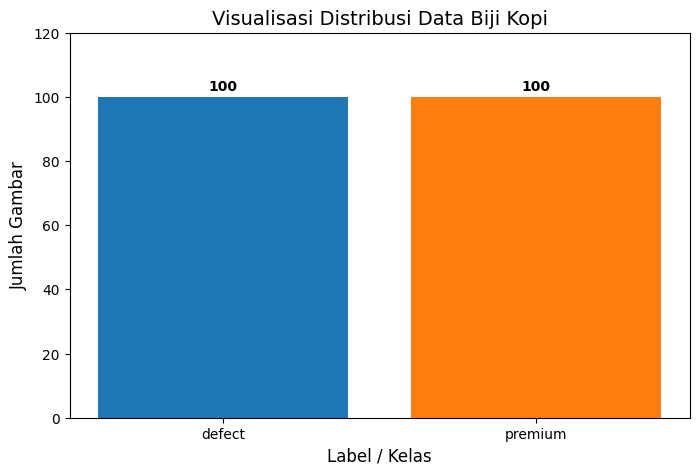

In [43]:
# Menghitung jumlah gambar untuk masing-masing label otomatis
unique_labels, counts = np.unique(labels, return_counts=True)

# Membuat grafik batang
plt.figure(figsize=(8, 5))
plt.bar(unique_labels, counts, color=['#1f77b4', '#ff7f0e'])
plt.title("Visualisasi Distribusi Data Biji Kopi", fontsize=14)
plt.xlabel("Label / Kelas", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)

# Menambahkan angka persis di atas batangnya biar keren
for i in range(len(unique_labels)):
    plt.text(i, counts[i] + 2, str(counts[i]), ha='center', fontweight='bold')

plt.ylim(0, max(counts) + 20) # Biar grafiknya nggak mentok atas
plt.show()

Menghitung jumlah gambar untuk setiap kelas secara otomatis. unique_labels berisi nama kelas seperti Normal dan Defect, sedangkan counts berisi jumlah gambar masing-masing kelas. Membuat grafik batang dengan ukuran 8x5 inci. Setiap kelas diberi warna berbeda, biru untuk kelas pertama dan oranye untuk kelas kedua, lalu ditambahkan judul dan label pada sumbu x dan y. Menambahkan angka jumlah gambar tepat di atas setiap batang grafik agar lebih mudah dibaca, dengan posisi sedikit di atas batang dan teks dicetak tebal. Mengatur batas atas sumbu y agar ada ruang kosong di atas batang tertinggi sehingga angka tidak terpotong, lalu menampilkan grafik.

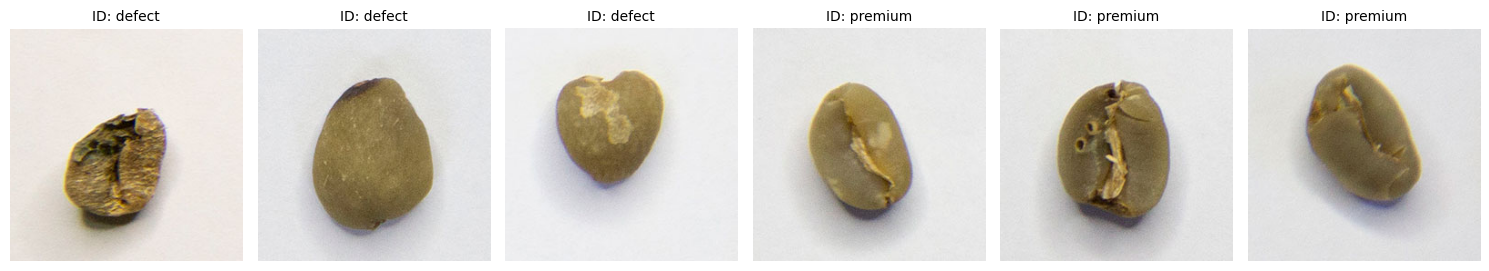

In [44]:
# 1. Cari urutan (indeks) gambar untuk masing-masing kelas
idx_defect = np.where(labels == 'defect')[0]
idx_premium = np.where(labels == 'premium')[0]

# 2. Ambil 3 gambar defect dan 3 gambar premium untuk dijadikan sampel
sample_indices = np.concatenate((idx_defect[:3], idx_premium[:3]))

plt.figure(figsize=(15, 3)) 

for i, idx in enumerate(sample_indices):
    plt.subplot(1, len(sample_indices), i + 1)
    
    # 3. Triknya di sini: Susun ulang alamat path gambar aslinya
    # labels[idx] berisi nama folder, file_name[idx] berisi nama file JPG-nya
    img_path = os.path.join("dataset", labels[idx], file_name[idx])
    
    # 4. Baca gambar aslinya dari folder (Format warnanya masih BGR dari OpenCV)
    img_bgr = cv.imread(img_path)
    
    # 5. Konversi warnanya dari BGR ke RGB biar nggak jadi "kopi avatar" (kebiruan)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    
    # Tampilkan gambar RGB-nya!
    plt.imshow(img_rgb)
    plt.title(f"ID: {labels[idx]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Mencari indeks posisi semua gambar yang berlabel defect dan premium di dalam array labels, sehingga bisa diakses secara spesifik per kelas. Mengambil 3 indeks pertama dari kelas defect dan 3 indeks pertama dari kelas premium, lalu digabungkan menjadi satu array berisi 6 indeks sampel. Membuat canvas berukuran 15x3 inci, lalu membuat layout subplot sebanyak 6 kolom dalam 1 baris untuk menampilkan setiap gambar sampel secara berdampingan. Menyusun ulang path gambar asli dari folder dataset menggunakan nama label sebagai subfolder dan nama file yang tersimpan di file_name, lalu membaca gambar tersebut dalam format BGR. Mengkonversi warna gambar dari BGR ke RGB karena OpenCV membaca gambar dalam format BGR, sedangkan matplotlib menampilkan dalam format RGB. Tanpa konversi ini warna gambar akan terlihat kebiruan. Menambahkan judul berisi nama kelas pada setiap gambar, menyembunyikan sumbu koordinat, merapikan jarak antar subplot, lalu menampilkan keseluruhan visualisasi.

## Data Augmentation

### Define Augmentation Function


In [45]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

Membuat empat list kosong sebagai wadah untuk menyimpan hasil augmentasi, yaitu gambar yang sudah diaugmentasi, label kelasnya, path filenya, dan nama filenya. Melakukan perulangan sebanyak jumlah gambar yang ada di dalam dataset. Kata pass berarti isi perulangan ini masih kosong dan belum diimplementasikan, kemungkinan akan diisi dengan proses augmentasi seperti rotasi, flip, atau perubahan kecerahan pada setiap gambar.

In [46]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


Menampilkan perbandingan jumlah gambar sebelum dan sesudah proses augmentasi dilakukan. Hasilnya akan menunjukkan seberapa banyak data baru yang berhasil dihasilkan dari proses augmentasi, di mana jumlah data setelah augmentasi seharusnya lebih banyak dari sebelumnya.

## Data Preparation

### Define Preprocessing Function


In [47]:
# ==========================================
# 1. KERNEL (Hanya yang dipakai)
# ==========================================
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

# ==========================================
# 2. FUNGSI DASAR
# ==========================================

def normalisasi(image):
    # Peregangan kontras manual
    image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return image.astype(np.uint8)

def histogram_equalization(image):
    height, width = image.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            hist[image[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(image, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[image[i, j]]
            
    return hasil

# ==========================================
# 3. FUNGSI SPASIAL (KONVOLUSI & FILTER)
# ==========================================
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for ki in range(size):
                        for kj in range(size):
                            total += int(region[ki, kj])
                    canvas[i, j] = total // area
                    
        case 'median':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * area
                    idx = 0
                    for ki in range(size):
                        for kj in range(size):
                            values[idx] = int(region[ki, kj])
                            idx += 1
                            
                    # Bubble sort manual
                    for a in range(area):
                        for b in range(0, area - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    canvas[i, j] = values[area // 2]
                    
    return canvas

Kernel untuk mempertajam gambar. Nilai tengah 8/9 yang lebih besar dari sekitarnya membuat piksel pusat lebih dominan sehingga tepi dan detail gambar terlihat lebih tajam. Dua kernel Sobel untuk mendeteksi tepi. sobelX mendeteksi perubahan intensitas arah horizontal, sedangkan sobelY mendeteksi perubahan arah vertikal. Fungsi normalisasi agar nilai piksel tersebar merata dari 0 sampai 255. Piksel paling gelap menjadi 0 dan paling terang menjadi 255.Fungsi histogram_equalization untuk menghitung histogram gambar secara manual, yaitu menghitung berapa banyak piksel untuk setiap nilai intensitas dari 0 sampai 255. Menghitung Cumulative Distribution Function (CDF) lalu dinormalisasi ke rentang 0-255. CDF digunakan sebagai tabel pemetaan nilai piksel baru agar distribusi intensitas menjadi lebih merata. fungsi convolution untuk operasi konvolusi manual antara gambar dan kernel. Setiap piksel dihitung dengan mengalikan area sekitarnya dengan nilai kernel lalu dijumlahkan. Padding ditambahkan agar ukuran output sama dengan input. Fungsi edge untuk mendeteksi tepi dengan menggabungkan hasil konvolusi sobelX dan sobelY. Nilai absolut keduanya dijumlahkan untuk mendapatkan kekuatan tepi di setiap piksel. Fungsi filter dengan dua mode. Mode mean menghitung rata-rata piksel dalam area kernel untuk menghaluskan gambar. Mode median mengurutkan nilai piksel menggunakan bubble sort manual lalu mengambil nilai tengahnya, yang lebih efektif untuk menghilangkan noise tanpa mengaburkan tepi gambar.

In [48]:
def resize(image, target_size=(128, 128)):
    old_height, old_width = image.shape[:2]
    new_height, new_width = target_size
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

def prepro1(image):
    # Eksperimen 1: Median Filter + Normalisasi (Manual)
    
    # 1. Filter median manual (size 3)
    img_median = filter(image, 3, 'median') # [cite: 1, 5, 10]
    
    # 2. Normalisasi manual
    img_norm = normalisasi(img_median) # [cite: 15, 16]
    
    return img_norm

def prepro2(image):
    # Eksperimen 2: Ekualisasi Histogram + Sharpening (Manual)
    
    # 1. Ekualisasi Histogram manual
    img_he = histogram_equalization(image) # [cite: 17, 18]
    
    # 2. Sharpening menggunakan konvolusi manual
    img_sharpened = convolution(img_he, kernelSharpening) # [cite: 19, 40, 41]
    
    # Konvolusi bisa menghasilkan nilai di luar 0-255, jadi kita pastikan formatnya aman
    return np.clip(img_sharpened, 0, 255).astype(np.uint8)

def prepro3(image):
    # Eksperimen 3: Smoothing + Edge Detection (Manual)
    
    # 1. Smoothing (mean filter ukuran 3) manual
    img_smooth = filter(image, 3, 'mean') # [cite: 1, 2, 4]
    
    # 2. Edge Detection Sobel manual
    img_edge = edge(img_smooth, sobelX, sobelY) # [cite: 19, 42, 43]
    
    return img_edge

Fungsi resize untuk mengubah ukuran gambar ke dimensi target secara manual menggunakan metode nearest neighbor. Setiap piksel pada gambar baru dipetakan ke posisi piksel terdekat di gambar asli berdasarkan perbandingan skala lebar dan tinggi. Fungsi prepro1: Median Filter + Normalisasi untuk pipeline preprocessing eksperimen pertama. Pertama gambar dihaluskan menggunakan median filter ukuran 3x3 untuk menghilangkan noise, lalu hasilnya dinormalisasi agar nilai piksel tersebar merata dari 0 sampai 255. Fungsi prepro2: Histogram Equalization + Sharpening untuk pipeline preprocessing eksperimen kedua. Pertama distribusi intensitas gambar diratakan menggunakan histogram equalization agar detail di area gelap maupun terang lebih terlihat, lalu dilakukan sharpening melalui konvolusi untuk mempertajam tepi dan detail gambar. Fungsi np.clip dipakai karena hasil konvolusi bisa menghasilkan nilai di luar rentang 0-255. Fungsi prepro3: Smoothing + Edge Detection untuk pipeline preprocessing eksperimen ketiga. Pertama gambar dihaluskan menggunakan mean filter ukuran 3x3 untuk mengurangi noise sebelum deteksi tepi, lalu diterapkan deteksi tepi Sobel pada kedua arah horizontal dan vertikal untuk menghasilkan gambar yang hanya menampilkan informasi tepi biji kopi.

### Preprocessing

In [49]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
dataPreprocessed = []
for i in range(len(data)): 
    # 1. Resize dulu pakai fungsi manual
    img_resized = resize(data[i], target_size=(128, 128))
    
    # 2. Panggil eksperimennya (Ganti prepro1 jadi prepro2 / prepro3 untuk tes yang lain)
    img_final = prepro2(img_resized) 
    
    # 3. Masukkan ke list
    dataPreprocessed.append(img_final)

dataPreprocessed = np.array(dataPreprocessed)
print(f"Selesai memproses {len(dataPreprocessed)} gambar.")

Selesai memproses 200 gambar.


Membuat list kosong sebagai wadah untuk menyimpan seluruh gambar yang sudah melalui proses preprocessing. Melakukan perulangan pada setiap gambar di dalam dataset, lalu mengubah ukurannya menjadi 128x128 piksel menggunakan fungsi resize manual agar semua gambar memiliki dimensi yang seragam sebelum diproses lebih lanjut. Menerapkan pipeline preprocessing eksperimen kedua yaitu Ekualisasi histogram dan sharpening pada gambar yang sudah di-resize, lalu menyimpan hasilnya ke dalam list. 

Jumlah gambar siap ekstrak (dataPreprocessed) : 200


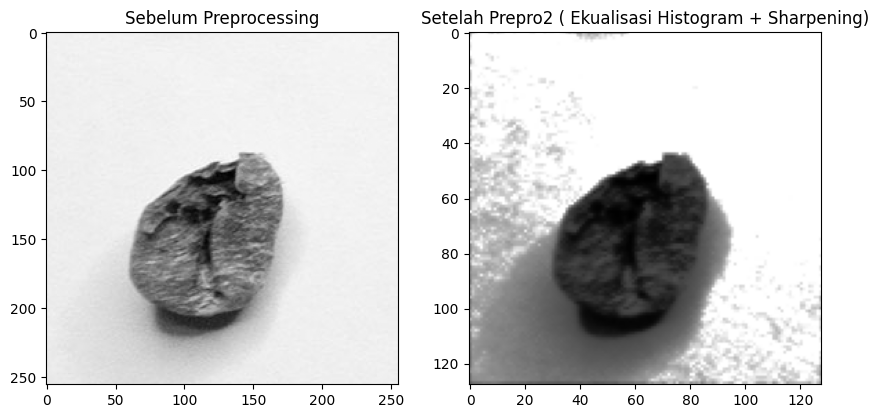

In [50]:
# 1. CEK ANGKA (Pastikan jumlahnya genap 200)
print(f"Jumlah gambar siap ekstrak (dataPreprocessed) : {len(dataPreprocessed)}")

# 2. CEK VISUAL (Bandingkan gambar asli vs hasil prepro2)
plt.figure(figsize=(10, 5))

# Gambar Original (Indeks ke-0)
plt.subplot(1, 2, 1)
plt.title("Sebelum Preprocessing")
plt.imshow(data[0], cmap='gray')

# Gambar Hasil Prepro2 (Indeks ke-0)
plt.subplot(1, 2, 2)
plt.title("Setelah Prepro2 ( Ekualisasi Histogram + Sharpening)")
plt.imshow(dataPreprocessed[0], cmap='gray')

plt.show()

print(f"Jumlah gambar siap ekstrak (dataPreprocessed) : {len(dataPreprocessed)}"), memverifikasi bahwa seluruh gambar telah berhasil melewati proses preprocessing tanpa ada data yang hilang, di mana jumlah akhirnya harus tetap sama dengan total data awal yakni 200 gambar. Selanjutnya,  membuat canvas berukuran 10x5 inci untuk menampilkan dua gambar secara berdampingan. Di sisi kiri, Anda menampilkan gambar asli pertama dari dataset dalam format grayscale, yang berfungsi sebagai standar acuan sebelum dilakukan perubahan apa pun. Di sisi kanan, Anda menampilkan gambar hasil preprocessing kedua, yang kini telah melalui proses Ekualisasi Histogram dan Sharpening. Terakhir, fungsi plt.show() digunakan untuk merender dan menampilkan seluruh hasil visualisasi.

### Feature Extraction

In [51]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi glcm(image, derajat) merupakan implementasi standar untuk mengekstraksi tekstur dari sebuah citra menggunakan Gray-Level Co-occurrence Matrix (GLCM). Fungsi ini sangat penting dalam analisis citra untuk mengukur bagaimana piksel-piksel dengan intensitas tertentu berulang dalam jarak satu piksel ([1]) pada arah tertentu. GLCM memerlukan input sudut 0°, 45°, 90°, dan 135° ke dalam format numpy. Membuat matriks GLCM dari gambar menggunakan fungsi graycomatrix dari skimage dengan parameter:
-[1] berarti jarak antar piksel yang dibandingkan adalah 1 piksel
-angles adalah sudut arah yang sudah dikonversi ke radian
-256 adalah jumlah level intensitas abu-abu
-symmetric=True membuat matriks simetris sehingga arah bolak-balik dianggap sama
-normed=True menormalisasi nilai matriks agar jumlah totalnya menjadi 1
Hasil matriks GLCM ini nantinya digunakan untuk mengekstraksi fitur tekstur seperti kontras, korelasi, energi, dan homogenitas.

In [52]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Mengekstraksi nilai fitur korelasi dari matriks GLCM menggunakan fungsi graycoprops. Korelasi mengukur seberapa konsisten hubungan linear antar piksel tetangga dalam gambar, nilai mendekati 1 menunjukkan tekstur yang sangat seragam dan berulang, sedangkan nilai mendekati -1 menunjukkan tekstur yang sangat acak. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari hasil output graycoprops yang berbentuk array.

In [53]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Mengekstraksi nilai fitur dissimilarity atau ketidakmiripan dari matriks GLCM. Dissimilarity mengukur seberapa berbeda nilai intensitas antar piksel tetangga dalam gambar, nilai tinggi menunjukkan perbedaan intensitas yang besar antar piksel sehingga tekstur terlihat kasar dan tidak seragam, sedangkan nilai rendah menunjukkan piksel-piksel yang berdekatan memiliki intensitas serupa sehingga tekstur terlihat halus. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari output graycoprops yang berbentuk array.

In [54]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Mengekstraksi nilai fitur homogenitas dari matriks GLCM. Homogenitas mengukur seberapa seragam distribusi intensitas piksel dalam gambar, nilai mendekati 1 menunjukkan tekstur yang sangat homogen dan merata seperti permukaan halus, sedangkan nilai mendekati 0 menunjukkan tekstur yang tidak seragam dengan variasi intensitas yang besar antar piksel tetangga. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari output graycoprops yang berbentuk array.

In [55]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Mengekstraksi nilai fitur kontras dari matriks GLCM. Kontras mengukur seberapa besar perbedaan intensitas antara piksel dan tetangganya di seluruh gambar, nilai tinggi menunjukkan perbedaan intensitas yang tajam seperti pada tepi objek atau tekstur kasar, sedangkan nilai rendah menunjukkan gambar yang cenderung seragam tanpa banyak variasi intensitas. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari output graycoprops yang berbentuk array.

In [56]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Mengekstraksi nilai fitur ASM atau Angular Second Moment dari matriks GLCM. ASM mengukur keseragaman tekstur gambar berdasarkan kuadrat dari setiap elemen matriks GLCM, nilai mendekati 1 menunjukkan tekstur yang sangat seragam dan teratur karena distribusi intensitas piksel terkonsentrasi pada sedikit nilai, sedangkan nilai mendekati 0 menunjukkan tekstur yang sangat bervariasi dan tidak beraturan. ASM juga sering disebut sebagai energi karena akar kuadrat dari ASM menghasilkan nilai energi tekstur. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari output graycoprops yang berbentuk array.

In [57]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Mengekstraksi nilai fitur energi dari matriks GLCM. Energi merupakan akar kuadrat dari ASM dan mengukur keseragaman tekstur gambar, nilai mendekati 1 menunjukkan tekstur yang sangat seragam dan teratur karena piksel-piksel memiliki pola intensitas yang konsisten, sedangkan nilai mendekati 0 menunjukkan tekstur yang sangat acak dan tidak beraturan. Perbedaannya dengan ASM adalah energi memiliki rentang nilai yang lebih intuitif karena merupakan hasil akar kuadrat sehingga lebih mudah diinterpretasikan. Indeks [0, 0] digunakan untuk mengambil nilai skalar tunggal dari output graycoprops yang berbentuk array.

In [58]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Mengekstraksi nilai fitur entropi dari matriks GLCM. Entropi mengukur tingkat ketidakteraturan atau kompleksitas tekstur gambar, nilai tinggi menunjukkan tekstur yang sangat acak dan kompleks karena distribusi intensitas piksel tersebar merata, sedangkan nilai rendah menunjukkan tekstur yang seragam dan mudah diprediksi. Berbeda dengan fungsi fitur GLCM lainnya, fungsi ini menggunakan entropy dari scipy dan bukan dari graycoprops, sehingga matriks GLCM perlu diratakan terlebih dahulu menjadi array satu dimensi menggunakan ravel() sebelum dihitung nilai entropinya.

In [59]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Proses ini diawali dengan inisialisasi empat list kosong, yaitu Derajat0, Derajat45, Derajat90, dan Derajat135, yang berfungsi sebagai wadah penyimpanan untuk menampung hasil matriks GLCM dari setiap orientasi sudut kemudian melakukan perulangan  pada seluruh dataset gambar yang telah melalui tahap preprocessing. 0 derajat untuk arah horizontal, 45 derajat untuk diagonal kanan atas, 90 derajat untuk arah vertikal, dan 135 derajat untuk diagonal kiri atas, bertujuan untuk menangkap informasi spasial dari berbagai arah yang berbeda. Setiap hasil perhitungan matriks GLCM kemudian disimpan ke dalam list yang relevan sesuai dengan sudut analisisnya.

In [60]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


Menginisialisasi 28 list kosong secara terstruktur sebagai wadah untuk menyimpan tujuh fitur statistik utama, yaitu Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, dan Correlation dari empat sudut orientasi yang berbeda. Untuk setiap kategori fitur tersebut, menyediakan empat list spesifik yang masing-masing merepresentasikan arah analisis 0 derajat, 45 derajat, 90 derajat, dan 135 derajat.

In [61]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Proses ini melibatkan iterasi pada seluruh koleksi matriks GLCM yang telah disiapkan sebelumnya untuk mengekstraksi fitur statistik korelasi dari keempat orientasi sudut yang berbeda. Dalam setiap iterasi,  mengambil matriks GLCM dari list Derajat0, Derajat45, Derajat90, dan Derajat135, kemudian menghitung nilai korelasinya menggunakan fungsi statistik yang relevan.

In [62]:
for i in range(len(Derajat0)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur kontras dari keempat sudut analisis. Setiap iterasi menghitung nilai kontras dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, lalu menyimpan hasilnya ke masing-masing list yang sesuai yaitu Kontras0, Kontras45, Kontras90, dan Kontras135.

In [63]:
for i in range(len(Derajat0)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur dissimilarity (ketidakmiripan) dari keempat sudut analisis. Setiap iterasi menghitung nilai ketidakmiripan dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, kemudian menyimpan hasilnya ke dalam list dissimilarity0, dissimilarity45, dissimilarity90, dan dissimilarity135.

In [64]:
for i in range(len(Derajat0)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur homogeneity (homogenitas) dari keempat sudut analisis. Setiap iterasi menghitung nilai tingkat keseragaman piksel dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, kemudian menyimpan hasilnya ke dalam list homogenity0, homogenity45, homogenity90, dan homogenity135.

In [65]:
for i in range(len(Derajat0)): 
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur entropy (entropi) dari keempat sudut analisis. Setiap iterasi menghitung tingkat kompleksitas atau ketidakteraturan distribusi piksel dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, lalu menyimpan hasilnya ke dalam list entropy0, entropy45, entropy90, dan entropy135. Fungsi entropyGlcm pada langkah ini memberikan ukuran seberapa acak atau kompleks tekstur yang ada pada permukaan biji kopi.

In [66]:
for i in range(len(Derajat0)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur Angular Second Moment (ASM) dari keempat sudut analisis. Setiap iterasi menghitung nilai ukuran keseragaman distribusi intensitas piksel dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, lalu menyimpan hasilnya ke dalam list ASM0, ASM45, ASM90, dan ASM135. Penggunaan fungsi ASM di sini memberikan ukuran seberapa besar tingkat keterulangan pola piksel dalam citra.

In [67]:
for i in range(len(Derajat0)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Proses ini melakukan perulangan pada setiap matriks GLCM untuk mengekstraksi nilai fitur energy (energi) dari keempat sudut analisis. Setiap iterasi menghitung nilai energi dari matriks GLCM sudut 0, 45, 90, dan 135 derajat secara berurutan, lalu menyimpan hasilnya ke dalam list energy0, energy45, energy90, dan energy135. Fungsi energy di sini berfungsi sebagai akar kuadrat dari Angular Second Moment (ASM), yang memberikan ukuran seberapa besar tingkat keterulangan intensitas piksel dalam sebuah citra.

### Write the extraction's results to CSV 

In [68]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
hasilEkstrak

# Cek detektif untuk mencari list yang jumlahnya tidak sama
for key, value in dataTable.items():
    print(f"{key}: {len(value)}")


Filename: 200
Label: 200
Contrast0: 200
Contrast45: 200
Contrast90: 200
Contrast135: 200
Homogeneity0: 200
Homogeneity45: 200
Homogeneity90: 200
Homogeneity135: 200
Dissimilarity0: 200
Dissimilarity45: 200
Dissimilarity90: 200
Dissimilarity135: 200
Entropy0: 200
Entropy45: 200
Entropy90: 200
Entropy135: 200
ASM0: 200
ASM45: 200
ASM90: 200
ASM135: 200
Energy0: 200
Energy45: 200
Energy90: 200
Energy135: 200
Correlation0: 200
Correlation45: 200
Correlation90: 200
Correlation135: 200


Proses ini diawali dengan pembuatan dictionary dataTable yang menggabungkan seluruh hasil ekstraksi fitur menjadi satu struktur data yang terpadu. Dictionary ini memetakan nama fitur ke masing-masing list yang telah terisi, dengan total 30 kolom yang terdiri dari nama file, label kelas, serta 28 nilai fitur tekstur hasil perhitungan GLCM dari empat sudut orientasi. Setelah struktur data terbentuk, mengubah dictionary tersebut menjadi DataFrame pandas dan menyimpannya ke dalam file lokal bernama hasil_ekstraksi_2.csv. Penggunaan parameter index=False memastikan bahwa indeks baris otomatis dari pandas tidak disertakan dalam file CSV, sehingga data tetap bersih dan siap digunakan kembali.

### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

<Axes: >

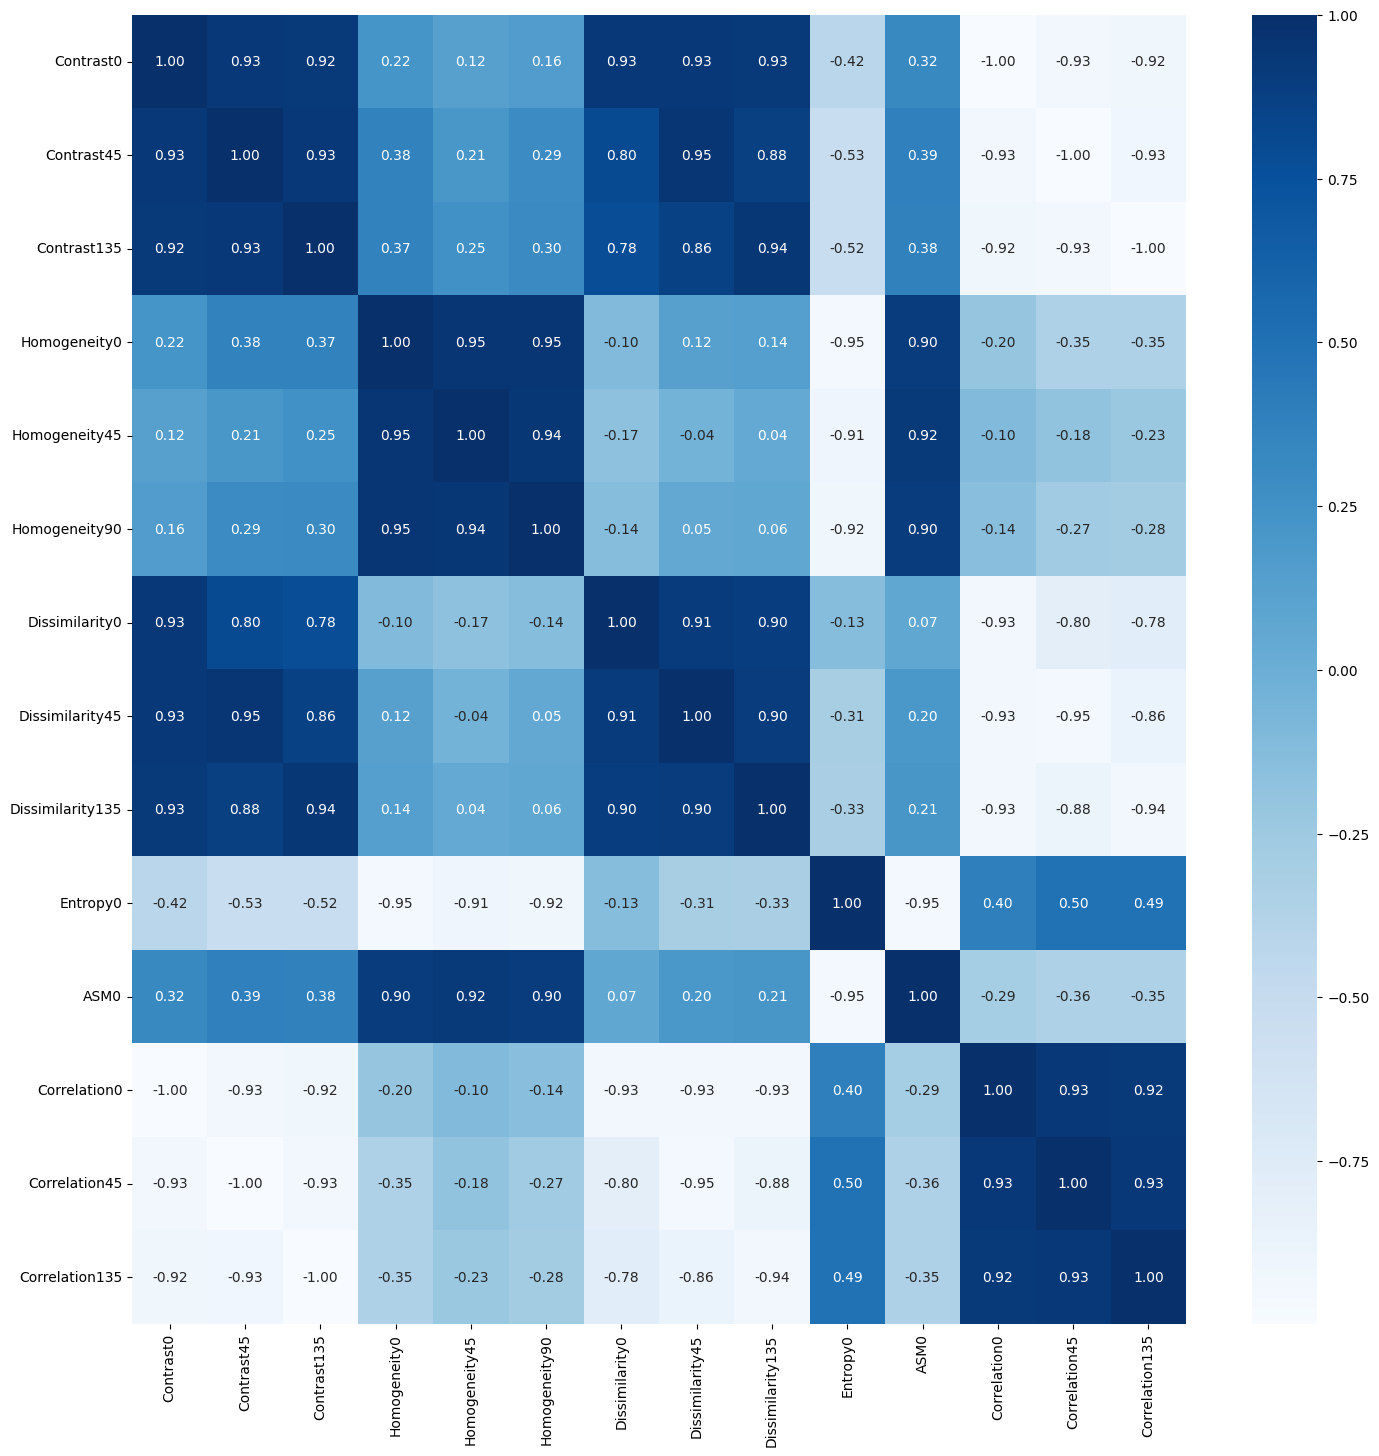

In [69]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

Menghitung matriks korelasi antar semua fitur tekstur dengan terlebih dahulu menghapus kolom Label dan Filename yang bukan merupakan fitur numerik. Melakukan seleksi fitur dengan menghapus fitur yang memiliki korelasi terlalu tinggi satu sama lain yaitu di atas 0.95. Array boolean columns digunakan sebagai penanda, jika dua fitur berkorelasi sangat tinggi maka fitur kedua ditandai False dan akan dihapus, karena fitur yang sangat berkorelasi hanya memberikan informasi yang redundan bagi model. Mengambil hanya kolom fitur yang lolos seleksi berdasarkan penanda boolean tadi sebagai fitur input model, lalu memisahkan kolom Label sebagai target output klasifikasi. Menampilkan heatmap korelasi antar fitur yang sudah diseleksi menggunakan seaborn dengan ukuran canvas 17x17 inci. Warna biru menunjukkan tingkat korelasi, angka pada setiap sel menampilkan nilai korelasi dengan dua angka desimal, sehingga dapat dilihat secara visual apakah masih ada fitur yang masih berkorelasi tinggi setelah proses seleksi.

## Splitting Data

In [70]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 14)
(40, 14)


Membagi dataset menjadi data latih dan data uji menggunakan fungsi train_test_split. Parameter yang digunakan yaitu test_size=0.2 berarti 20% data digunakan untuk pengujian dan 80% sisanya untuk pelatihan, sedangkan random_state=42 digunakan agar pembagian data selalu menghasilkan hasil yang sama setiap kali kode dijalankan sehingga hasil eksperimen dapat direproduksi. Menampilkan dimensi dari data latih dan data uji dalam format baris x kolom. Baris menunjukkan jumlah gambar dan kolom menunjukkan jumlah fitur yang digunakan, sehingga dapat diverifikasi bahwa pembagian data sudah sesuai dengan proporsi yang diinginkan.

## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [71]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Melakukan normalisasi Z-score pada data latih dan data uji agar semua fitur berada pada skala yang sama. Rumusnya adalah nilai fitur dikurangi rata-rata lalu dibagi dengan standar deviasi, sehingga setiap fitur akan memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. keduanya menggunakan X_train.mean() dan X_train.std() sebagai acuan normalisasi, bukan dari X_test. Ini adalah praktik yang benar karena dalam skenario nyata data uji dianggap belum pernah dilihat sebelumnya, sehingga parameter normalisasi hanya boleh dihitung dari data latih untuk menghindari kebocoran data atau data leakage yang bisa membuat evaluasi model menjadi tidak valid.

## Modeling

### Define Model

In [72]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Fungsi generateClassificationReport untuk menampilkan metrik evaluasi secara lengkap guna memahami seberapa baik model dalam melakukan klasifikasi. classification_report(y_true, y_pred) untuk menampilkan metrik utama seperti Precision, Recall, F1-Score, dan Support untuk setiap kelas. Ini sangat berguna untuk melihat apakah model bias terhadap kelas tertentu. confusion_matrix(y_true, y_pred) untuk Menampilkan matriks yang menunjukkan perbandingan antara nilai aktual (true) dan prediksi model. Ini membantu mengidentifikasi kesalahan spesifik, seperti kelas mana yang sering tertukar.
accuracy_score(y_true, y_pred) untuk Menghitung rasio prediksi yang benar dibandingkan dengan total data.

### Train Random Forest Classifier

In [73]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      defect       0.97      0.90      0.93        79
     premium       0.91      0.98      0.94        81

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160

[[71  8]
 [ 2 79]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

      defect       0.64      0.86      0.73        21
     premium       0.75      0.47      0.58        19

    accuracy                           0.68        40
   macro avg       0.70      0.67      0.66        40
weighted avg       0.69      0.68      0.66        40

[[18  3]
 [10  9]]
Accuracy: 0.675


Menjalankan rf.fit(X_train, y_train), di mana model Random Forest mempelajari pola tekstur biji kopi dari fitur-fitur yang telah terseleksi sebelumnya. Proses ini membangun kumpulan pohon keputusan (decision trees) yang secara kolektif akan menentukan kelas mutu biji kopi berdasarkan nilai-nilai fitur yang telah diekstraksi. Dengan menggunakan fungsi generateClassificationReport(y_train, y_pred), menampilkan metrik seperti Precision, Recall, F1-Score, dan support. Menguji model dengan X_test, yaitu data yang belum pernah dilihat oleh model selama proses pelatihan. Evaluasi pada testing set ini sangat penting untuk memastikan apakah model memiliki kemampuan generalisasi yang baik atau justru mengalami overfitting (terlalu kaku pada data latih).

### Train SVM Classifier

In [74]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      defect       0.81      0.80      0.80        79
     premium       0.80      0.81      0.81        81

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160

[[63 16]
 [15 66]]
Accuracy: 0.80625

------Testing Set------
              precision    recall  f1-score   support

      defect       0.73      0.76      0.74        21
     premium       0.72      0.68      0.70        19

    accuracy                           0.72        40
   macro avg       0.72      0.72      0.72        40
weighted avg       0.72      0.72      0.72        40

[[16  5]
 [ 6 13]]
Accuracy: 0.725


Menjalankan svm.fit(X_train, y_train), di mana model SVM mempelajari garis batas (hyperplane) optimal untuk memisahkan kelas-kelas kualitas biji kopi berdasarkan fitur tekstur yang telah diekstraksi. SVM bekerja dengan mencari margin terbesar antar kelas, menjadikannya sangat efektif untuk klasifikasi yang berbasis pada fitur statistik. Dengan memanggil generateClassificationReport(y_train, y_pred), menampilkan metrik penting seperti Precision, Recall, F1-Score, dan support. Menguji model dengan data baru yang belum pernah dilihat sebelumnya, yakni X_test. Evaluasi pada testing set ini sangat krusial untuk memastikan kemampuan generalisasi model mampu melakukan prediksi yang akurat pada data di luar data latihan, atau justru mengalami overfitting yang membuat performanya menurun saat menghadapi data yang berbeda.

### Train KNN Classifier

In [75]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

      defect       0.89      0.80      0.84        79
     premium       0.82      0.90      0.86        81

    accuracy                           0.85       160
   macro avg       0.85      0.85      0.85       160
weighted avg       0.85      0.85      0.85       160

[[63 16]
 [ 8 73]]
Accuracy: 0.85

------Testing Set------
              precision    recall  f1-score   support

      defect       0.56      0.48      0.51        21
     premium       0.50      0.58      0.54        19

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.53      0.53      0.52        40

[[10 11]
 [ 8 11]]
Accuracy: 0.525


Menjalankan knn.fit(X_train, y_train). Berbeda dengan model lainnya, KNN tidak membangun model melainkan menyimpan seluruh data latih untuk digunakan sebagai referensi saat proses prediksi. KNN akan memetakan setiap biji kopi ke dalam ruang fitur multidimensi berdasarkan karakteristik teksturnya. Dengan memanggil generateClassificationReport(y_train, y_pred), menampilkan metrik penting seperti Precision, Recall,F1-Score dan support. Menguji model dengan data yang belum pernah dilihat sebelumnya, yaitu X_test. Pada tahap ini, model KNN akan mencari k tetangga terdekat dari data uji di dalam ruang fitur yang telah dibentuk oleh data latih. Evaluasi pada testing set sangat krusial untuk memastikan kemampuan generalisasi model mampu melakukan prediksi yang akurat pada data baru, atau justru sensitif terhadap noise yang mungkin ada dalam data latih.

## Evaluation With Confusion Matrix

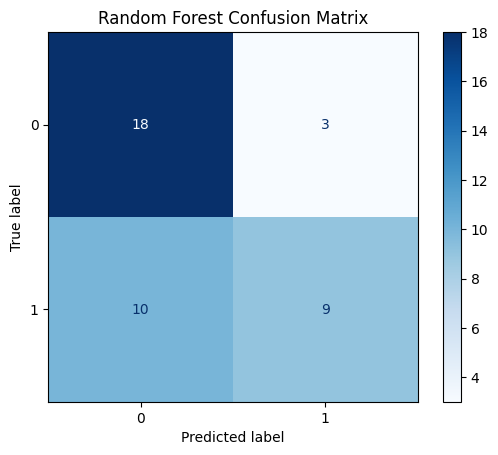

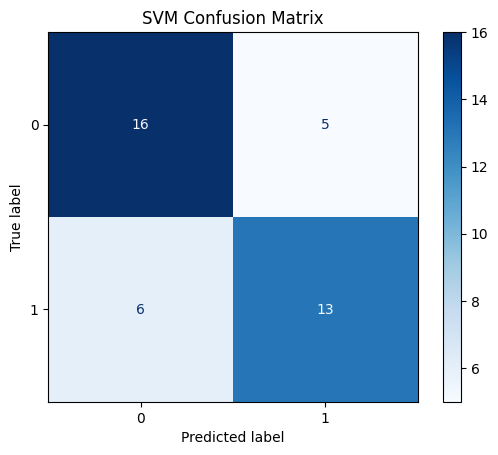

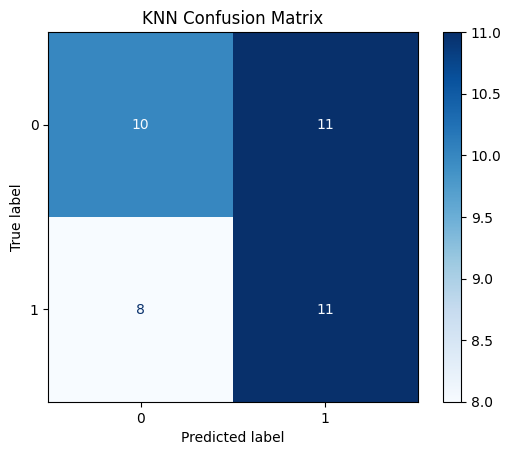

In [76]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

Fungsi plot_confusion_matrix mengambil y_true (label asli) dan y_pred (hasil prediksi model) sebagai input, lalu menghitung matriks melalui confusion_matrix. Output visual berupa heatmap berwarna biru memudahkan untuk mengidentifikasi klasifikasi yang benar pada diagonal utama dan kesalahan prediksi di luar diagonal tersebut, sehingga bisa dengan cepat membandingkan reliabilitas antara Random Forest, SVM, dan KNN.